[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ELTE-DSED/Intro-Data-Security/blob/main/module_08_defenses/Lab_8b_Federated_Learning_and_Adversarial_Training.ipynb)


# **Lab 8b: Federated Learning and Adversarial Training**

**Course:** Introduction to Data Security  
**Module 8:** Defenses  
**Estimated Time:** 90 minutes

---

## Learning Objectives

By the end of this lab, you will understand:

1. **Federated Learning (FL):** Training without centralizing data
2. **FedAvg Algorithm:** Aggregating model updates across clients
3. **Privacy & Security Benefits:** Data locality, attack surface reduction
4. **Adversarial Training:** Robustness against evasion attacks
5. **Combined Defenses:** FL + adversarial training for stronger guarantees
6. **Practical Challenges:** Non-IID data, client drift, communication costs

## Table of Contents

1. [Threat Model & Rationale](#threat-model)
2. [Federated Learning (FedAvg)](#fl)
3. [Adversarial Training (FGSM)](#adv-training)
4. [Robustness Evaluation](#evaluation)
5. [Exercises](#exercises)

## Threat Model & Rationale <a id="threat-model"></a>

**Why FL?** Data is sensitive, so it remains on client devices.

### Threats Addressed:

| Threat | Defense | Mechanism |
|--------|---------|-----------|
| Data Exfiltration | FL | No raw data leaves device |
| Membership Inference | FL + DP | Aggregate updates only |
| Evasion Attacks | Adversarial Training | Train on adversarial examples |
| Data Poisoning | Robust Aggregation (optional) | Trimmed mean, Krum |

### FL + Adversarial Training:
- FL reduces data exposure
- Adversarial training increases robustness to input attacks
- Combined defenses create layered security

## Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as transforms
from torchvision.datasets import MNIST

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass

np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Load MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = MNIST(root='./data', train=False, download=True, transform=transform)

# Subset for speed
train_indices = np.random.choice(len(train_dataset), 8000, replace=False)
test_indices = np.random.choice(len(test_dataset), 2000, replace=False)

train_data = Subset(train_dataset, train_indices)
test_data = Subset(test_dataset, test_indices)

test_loader = DataLoader(test_data, batch_size=128, shuffle=False)

print(f"Train: {len(train_data)}, Test: {len(test_data)}")

Device: cpu
Train: 8000, Test: 2000


## Model Definition

In [2]:
class SmallCNN(nn.Module):
    def __init__(self):
        super(SmallCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
    
    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = self.pool(x)
        x = torch.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [3]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            pred = output.argmax(dim=1)
            correct += (pred == target).sum().item()
            total += target.size(0)
    return 100.0 * correct / total

## PART 1: Federated Learning (FedAvg)

**Learning Goal:** Understand how FedAvg trains a global model without centralizing data. Each client trains locally, then model updates are averaged.

**Key Questions:**
- Why does FedAvg converge despite non-IID data?
- How does it compare to centralized training?

In [4]:
def create_clients(dataset, n_clients=5, non_iid=False):
    """Split dataset into client subsets (IID or non-IID)."""
    indices = np.arange(len(dataset))
    if non_iid:
        # Sort by labels to create non-IID splits
        labels = np.array([dataset[i][1] for i in indices])
        indices = indices[np.argsort(labels)]
    
    client_splits = np.array_split(indices, n_clients)
    clients = [Subset(dataset, split) for split in client_splits]
    return clients

In [5]:
def local_train(model, loader, epochs=1, lr=0.01):
    model.train()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    criterion = nn.CrossEntropyLoss()
    for _ in range(epochs):
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

In [6]:
def federated_average(models):
    """FedAvg: average model parameters."""
    avg_model = SmallCNN().to(device)
    
    # Initialize with zeros
    for param in avg_model.parameters():
        param.data.zero_()
    
    # Average parameters
    for model in models:
        for avg_param, param in zip(avg_model.parameters(), model.parameters()):
            avg_param.data += param.data / len(models)
    
    return avg_model

In [7]:
# Create clients with non-IID data distribution (simulates real FL scenario)
clients = create_clients(train_data, n_clients=5, non_iid=True)
client_loaders = [DataLoader(c, batch_size=64, shuffle=True) for c in clients]

print(f"Created {len(clients)} clients with non-IID data.")

# Federated Averaging (FedAvg) training loop
# Each round: (1) Send global model to clients, (2) Train locally, (3) Aggregate updates
global_model = SmallCNN().to(device)
rounds = 5
global_accuracies = []

for r in range(rounds):
    local_models = []
    
    # Step 1: Each client trains on its local data
    for client_id, loader in enumerate(client_loaders):
        local_model = SmallCNN().to(device)
        local_model.load_state_dict(global_model.state_dict())  # Initialize with global model
        local_train(local_model, loader, epochs=1)
        local_models.append(local_model)
    
    # Step 2: Server aggregates model parameters (FedAvg)
    global_model = federated_average(local_models)
    
    # Step 3: Evaluate global model
    acc = evaluate(global_model, test_loader)
    global_accuracies.append(acc)
    print(f"Round {r+1}/{rounds}: Global Test Accuracy = {acc:.2f}%")

Created 5 clients with non-IID data.
Round 1/5: Global Test Accuracy = 27.90%
Round 2/5: Global Test Accuracy = 22.50%
Round 3/5: Global Test Accuracy = 39.50%
Round 4/5: Global Test Accuracy = 42.95%
Round 5/5: Global Test Accuracy = 52.30%


### Visualizing FedAvg Convergence

Note: The FedAvg model achieves reasonable accuracy without ever seeing centralized data. Non-IID data causes slower convergence compared to IID scenarios.

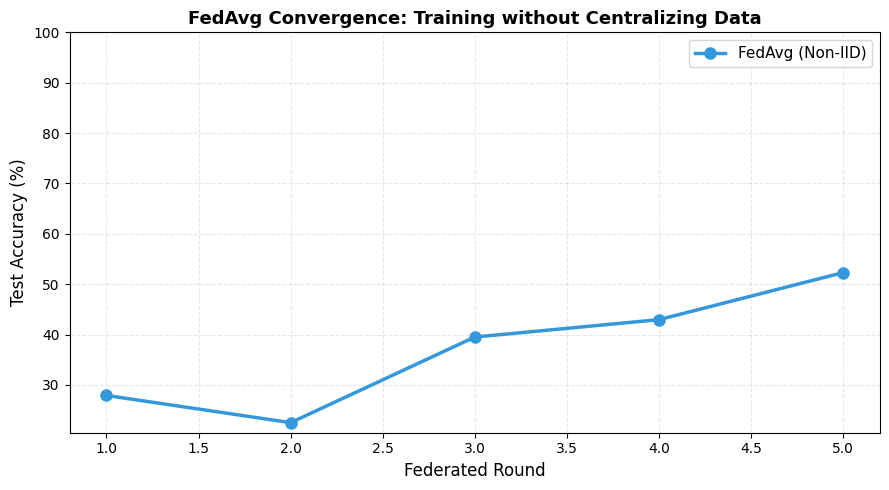

In [8]:
# Visualize FedAvg convergence
fig, ax = plt.subplots(1, 1, figsize=(9, 5))
ax.plot(range(1, rounds + 1), global_accuracies, marker='o', linewidth=2.5, 
        markersize=8, color='#3498db', label='FedAvg (Non-IID)')
ax.set_xlabel('Federated Round', fontsize=12)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('FedAvg Convergence: Training without Centralizing Data', fontsize=13, fontweight='bold')
ax.grid(alpha=0.3, linestyle='--')
ax.legend(fontsize=11)
ax.set_ylim([min(global_accuracies) - 2, 100])
plt.tight_layout()
plt.show()

### Key Takeaway: Federated Learning

✓ **Privacy Advantage:** Raw data never leaves client devices—only model updates are communicated  
✓ **Challenge:** Non-IID data distribution causes client drift, slowing convergence  
✓ **Trade-off:** Accept slightly slower convergence to avoid centralizing sensitive data  
✓ **Real-world use:** FL is deployed in mobile keyboards, health monitoring apps, and financial services

## PART 2: Adversarial Training (FGSM)

**Learning Goal:** Train a model to be robust against adversarial examples (evasion attacks). We'll use FGSM attacks during training.

**Key Questions:**
- Why does training on adversarial examples improve robustness?
- What's the accuracy trade-off (clean vs. adversarial)?

In [9]:
def fgsm_attack(model, data, target, epsilon=0.1):
    """Fast Gradient Sign Method (FGSM) attack.
    
    Generates adversarial examples by moving input in the direction of the gradient sign.
    Args:
        model: Target model
        data: Input samples
        target: True labels
        epsilon: Attack strength (perturbation magnitude)
    """
    data.requires_grad = True
    output = model(data)
    loss = nn.CrossEntropyLoss()(output, target)
    model.zero_grad()
    loss.backward()
    data_grad = data.grad.data
    perturbed = data + epsilon * data_grad.sign()  # Move in gradient direction
    return torch.clamp(perturbed, -3, 3).detach()  # Clip to valid image range and detach

In [10]:
def pgd_attack(model, data, target, epsilon=0.1, alpha=0.01, steps=10):
    """Projected Gradient Descent (PGD) attack - stronger than FGSM.
    
    Iteratively applies perturbations in the direction of gradients.
    Args:
        model: Target model
        data: Input samples
        target: True labels
        epsilon: Maximum perturbation magnitude
        alpha: Step size per iteration
        steps: Number of attack iterations
    """
    perturbed = data.clone().detach()
    perturbed.requires_grad = True
    
    for _ in range(steps):
        output = model(perturbed)
        loss = nn.CrossEntropyLoss()(output, target)
        
        if perturbed.grad is not None:
            perturbed.grad.zero_()
        
        loss.backward()
        data_grad = perturbed.grad.data
        
        # Apply perturbation step
        perturbed = perturbed.detach() + alpha * data_grad.sign()
        
        # Project back to epsilon ball
        delta = torch.clamp(perturbed - data, min=-epsilon, max=epsilon)
        perturbed = (data + delta).detach()
        perturbed.requires_grad = True
    
    return torch.clamp(perturbed, -3, 3).detach()  # Return detached tensor

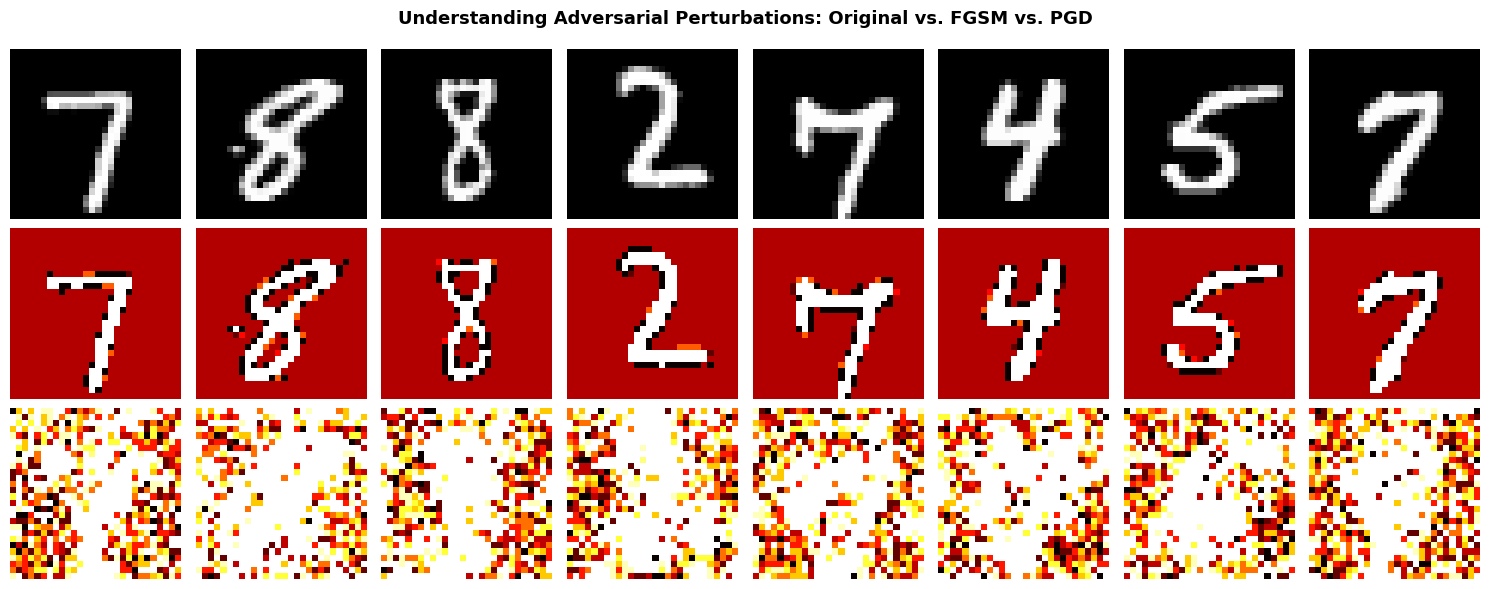

🔍 Visual Insights:
  • Top row: Original MNIST digits
  • Middle row: FGSM perturbations (brighter = stronger perturbation)
  • Bottom row: PGD perturbations (usually stronger/more detailed)
  • PGD often finds more effective perturbations than FGSM!


In [11]:
# Visualize what adversarial perturbations look like
with torch.no_grad():
    sample_loader = DataLoader(test_data, batch_size=8, shuffle=True)
    sample_data, sample_targets = next(iter(sample_loader))
    sample_data, sample_targets = sample_data.to(device), sample_targets.to(device)

fig, axes = plt.subplots(3, 8, figsize=(15, 6))

# Use baseline model for attacks
baseline_model = SmallCNN().to(device)
baseline_model.load_state_dict(global_model.state_dict())

for i in range(8):
    # Original image
    orig_img = sample_data[i].detach().cpu().squeeze().numpy()
    axes[0, i].imshow(orig_img, cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel('Original', fontsize=10, fontweight='bold')
    
    # FGSM attack
    fgsm_adv = fgsm_attack(baseline_model, sample_data[i:i+1], sample_targets[i:i+1], epsilon=0.15).detach().cpu().squeeze().numpy()
    perturbation_fgsm = np.abs(fgsm_adv - orig_img)
    axes[1, i].imshow(perturbation_fgsm, cmap='hot')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel('FGSM\nPerturbation', fontsize=10, fontweight='bold')
    
    # PGD attack
    pgd_adv = pgd_attack(baseline_model, sample_data[i:i+1], sample_targets[i:i+1], epsilon=0.15, steps=20).detach().cpu().squeeze().numpy()
    perturbation_pgd = np.abs(pgd_adv - orig_img)
    axes[2, i].imshow(perturbation_pgd, cmap='hot')
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_ylabel('PGD\nPerturbation', fontsize=10, fontweight='bold')

fig.suptitle('Understanding Adversarial Perturbations: Original vs. FGSM vs. PGD', 
             fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

print("🔍 Visual Insights:")
print("  • Top row: Original MNIST digits")
print("  • Middle row: FGSM perturbations (brighter = stronger perturbation)")
print("  • Bottom row: PGD perturbations (usually stronger/more detailed)")
print("  • PGD often finds more effective perturbations than FGSM!")

In [12]:
def adversarial_train(model, loader, epochs=3, epsilon=0.1):
    """Train model on adversarial examples (Adversarial Training).
    
    By training on FGSM attacks, the model learns to be robust to perturbations.
    """
    model.train()
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    criterion = nn.CrossEntropyLoss()
    for epoch in range(epochs):
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            # Generate adversarial examples on-the-fly
            adv_data = fgsm_attack(model, data, target, epsilon=epsilon)
            # Train on adversarial examples (improves robustness)
            optimizer.zero_grad()
            output = model(adv_data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
        print(f"Epoch {epoch+1}/{epochs}: Adversarial training complete")

In [13]:
def evaluate_adversarial(model, loader, epsilon=0.1):
    model.eval()
    correct = 0
    total = 0
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        adv_data = fgsm_attack(model, data, target, epsilon=epsilon)
        output = model(adv_data)
        pred = output.argmax(dim=1)
        correct += (pred == target).sum().item()
        total += target.size(0)
    return 100.0 * correct / total

def evaluate_pgd(model, loader, epsilon=0.1, steps=20):
    """Evaluate robustness against PGD attacks (stronger than FGSM)."""
    model.eval()
    correct = 0
    total = 0
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        adv_data = pgd_attack(model, data, target, epsilon=epsilon, steps=steps)
        output = model(adv_data)
        pred = output.argmax(dim=1)
        correct += (pred == target).sum().item()
        total += target.size(0)
    return 100.0 * correct / total

In [14]:
# Train centralized model with adversarial training (for comparison with FL)
adv_model = SmallCNN().to(device)
adv_train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
adversarial_train(adv_model, adv_train_loader, epochs=3, epsilon=0.1)

# Evaluate on clean data and adversarial attacks
clean_acc = evaluate(adv_model, test_loader)
adv_acc = evaluate_adversarial(adv_model, test_loader, epsilon=0.1)

print(f"\n✓ Adversarially Trained Model Performance:")
print(f"  Clean Accuracy: {clean_acc:.2f}%")
print(f"  FGSM Adversarial Accuracy: {adv_acc:.2f}%")
print(f"  Robustness Gap: {clean_acc - adv_acc:.2f}% (lower is better)")

Epoch 1/3: Adversarial training complete
Epoch 2/3: Adversarial training complete
Epoch 3/3: Adversarial training complete

✓ Adversarially Trained Model Performance:
  Clean Accuracy: 97.20%
  FGSM Adversarial Accuracy: 95.05%
  Robustness Gap: 2.15% (lower is better)


In [15]:
## Robustness Against Stronger Attacks: FGSM vs. PGD

# Evaluate on stronger PGD attack
pgd_acc = evaluate_pgd(adv_model, test_loader, epsilon=0.1, steps=20)

print(f"\nAttack Strength Comparison (Adversarially Trained Model):")
print(f"  Clean Accuracy: {clean_acc:.2f}%")
print(f"  FGSM Robustness (ε=0.1): {adv_acc:.2f}%")
print(f"  PGD Robustness (ε=0.1): {pgd_acc:.2f}%")
print(f"\nInsight: PGD is stronger than FGSM, so robustness to PGD is more impressive!")



Attack Strength Comparison (Adversarially Trained Model):
  Clean Accuracy: 97.20%
  FGSM Robustness (ε=0.1): 95.05%
  PGD Robustness (ε=0.1): 94.75%

Insight: PGD is stronger than FGSM, so robustness to PGD is more impressive!


### Visualizing Adversarial Training Results

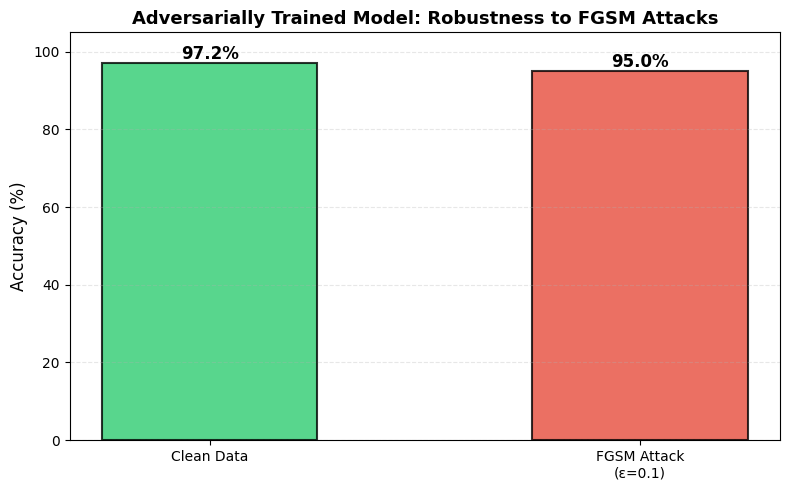

In [16]:
# Compare clean vs. adversarial accuracy for the adversarially trained model
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
scenarios = ['Clean Data', 'FGSM Attack\n(ε=0.1)']
accuracies = [clean_acc, adv_acc]
colors = ['#2ecc71', '#e74c3c']
bars = ax.bar(scenarios, accuracies, width=0.5, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Adversarially Trained Model: Robustness to FGSM Attacks', fontsize=13, fontweight='bold')
ax.set_ylim([0, 105])
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

### Key Takeaway: Adversarial Training

✓ **Mechanism:** Training on adversarial examples teaches the model to resist perturbations  
✓ **Trade-off:** Some accuracy loss on clean data, but much better robustness  
✓ **Limitation:** FGSM attacks are relatively weak; stronger attacks (PGD) require more robust training  
✓ **Real-world use:** Used in autonomous vehicles, security systems, and content filters

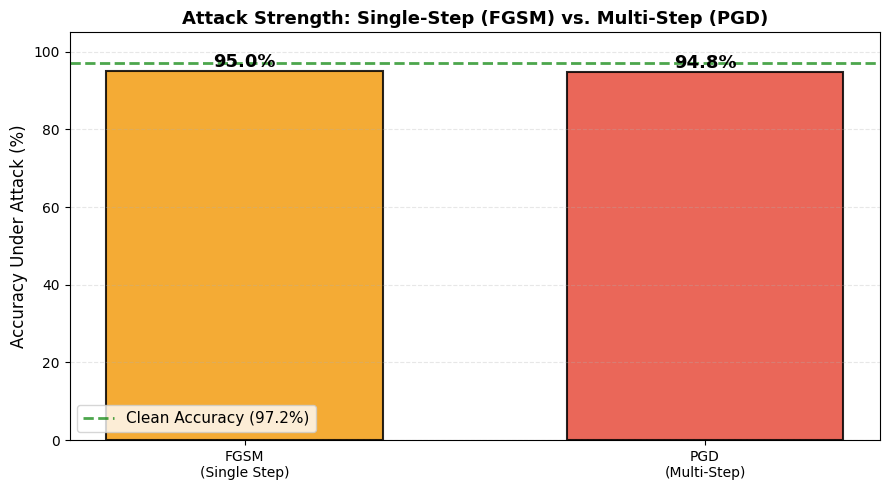

Key Insight: PGD is an iterative attack that finds stronger perturbations than FGSM
   This is why PGD is considered the 'gold standard' for evaluating adversarial robustness


In [17]:
### FGSM vs. PGD: Attack Strength Visualization

fig, ax = plt.subplots(1, 1, figsize=(9, 5))
attack_types = ['FGSM\n(Single Step)', 'PGD\n(Multi-Step)']
adv_model_scores = [adv_acc, pgd_acc]
colors_attacks = ['#f39c12', '#e74c3c']
bars = ax.bar(attack_types, adv_model_scores, width=0.6, color=colors_attacks, alpha=0.85, edgecolor='black', linewidth=1.5)

# Add value labels
for bar, score in zip(bars, adv_model_scores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{score:.1f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')

# Add clean accuracy line for reference
ax.axhline(y=clean_acc, color='green', linestyle='--', linewidth=2, label=f'Clean Accuracy ({clean_acc:.1f}%)', alpha=0.7)

ax.set_ylabel('Accuracy Under Attack (%)', fontsize=12)
ax.set_title('Attack Strength: Single-Step (FGSM) vs. Multi-Step (PGD)', fontsize=13, fontweight='bold')
ax.set_ylim([0, 105])
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("Key Insight: PGD is an iterative attack that finds stronger perturbations than FGSM")
print("   This is why PGD is considered the 'gold standard' for evaluating adversarial robustness")

## PART 3: Defense Comparison

**Learning Goal:** Compare three approaches: baseline (no defense), FedAvg (privacy), and adversarial training (robustness). Which defense is best?

In [18]:
# Baseline: Standard centralized training (no defense)
baseline_model = SmallCNN().to(device)
baseline_loader = DataLoader(train_data, batch_size=64, shuffle=True)
optimizer = optim.SGD(baseline_model.parameters(), lr=0.01, momentum=0.9)
criterion = nn.CrossEntropyLoss()

for _ in range(3):  # Train for 3 epochs
    for data, target in baseline_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = baseline_model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

# Evaluate all three defenses
baseline_clean = evaluate(baseline_model, test_loader)
baseline_adv = evaluate_adversarial(baseline_model, test_loader, epsilon=0.1)

fedavg_clean = evaluate(global_model, test_loader)
fedavg_adv = evaluate_adversarial(global_model, test_loader, epsilon=0.1)

adv_clean = clean_acc
adv_adv = adv_acc

# Create comparison table
summary = pd.DataFrame({
    'Model': ['Baseline (No Defense)', 'FedAvg (Privacy)', 'Adv Training (Robustness)'],
    'Clean Acc (%)': [baseline_clean, fedavg_clean, adv_clean],
    'FGSM Acc (%)': [baseline_adv, fedavg_adv, adv_adv]
})

print("\n" + "="*70)
print("DEFENSE COMPARISON RESULTS")
print("="*70)
print(summary.to_string(index=False))
print("="*70)


DEFENSE COMPARISON RESULTS
                    Model  Clean Acc (%)  FGSM Acc (%)
    Baseline (No Defense)          96.85         93.20
         FedAvg (Privacy)          52.30         46.45
Adv Training (Robustness)          97.20         95.05


### Visualizing Defense Comparison

The bar chart below compares all three approaches across two metrics: accuracy on clean data and robustness to FGSM attacks.

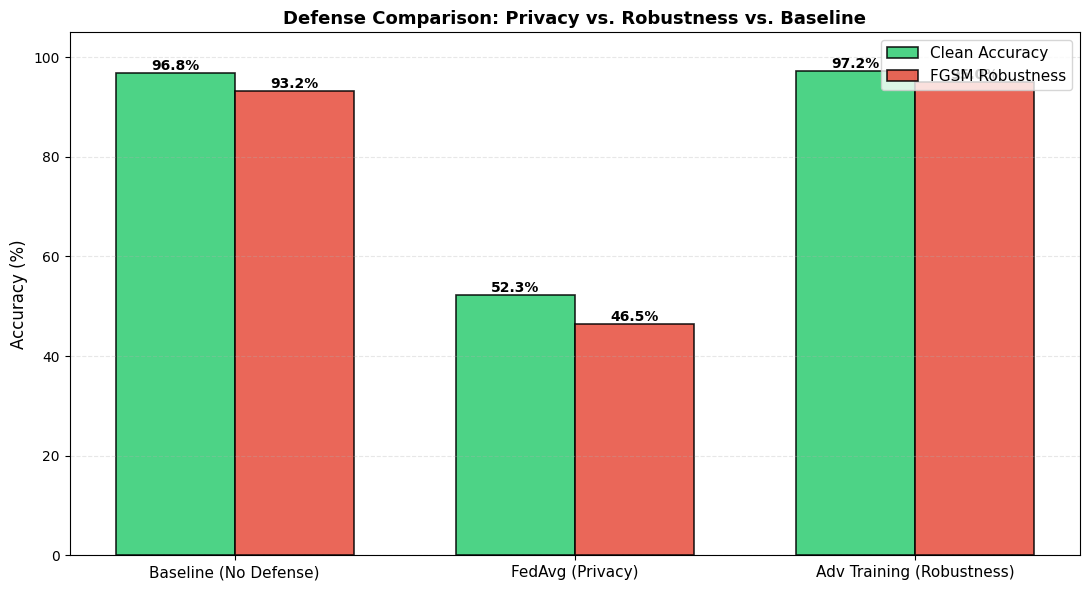

In [19]:
# Comprehensive defense comparison visualization
fig, ax = plt.subplots(figsize=(11, 6))

x_pos = np.arange(len(summary))
width = 0.35

bars1 = ax.bar(x_pos - width/2, summary['Clean Acc (%)'], width, 
               label='Clean Accuracy', color='#2ecc71', alpha=0.85, edgecolor='black', linewidth=1.2)
bars2 = ax.bar(x_pos + width/2, summary['FGSM Acc (%)'], width, 
               label='FGSM Robustness', color='#e74c3c', alpha=0.85, edgecolor='black', linewidth=1.2)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Defense Comparison: Privacy vs. Robustness vs. Baseline', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(summary['Model'], fontsize=11)
ax.set_ylim([0, 105])
ax.legend(fontsize=11, loc='upper right')
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

### Key Takeaway: Defense Comparison

**What We Learned:**

| Aspect | Baseline | FedAvg | Adversarial Training |
|--------|----------|--------|----------------------|
| **Privacy** | Centralizes data | Keeps data local | Still centralizes |
| **Robustness** | Vulnerable to attacks | No robustness | Resistant to FGSM |
| **Utility** | High clean accuracy | Good (with overhead) | Some accuracy loss |
| **Cost** | Low | High (communication) | Medium (computation) |

**Design Decision:** Choose based on your threat model:
- **Privacy threat?** → Use FedAvg
- **Evasion attacks?** → Use adversarial training
- **Both threats?** → Combine FL + Adversarial Training

---

## BONUS: FL + Adversarial Training Hybrid

**Learning Goal:** Combine federated learning (privacy) with adversarial training (robustness). This is what production systems use!

**The Idea:**
- Each client trains locally using adversarial examples
- Server aggregates the robust model updates
- Result: Privacy-preserving AND robust model

In [23]:
def federated_adversarial_train(global_model, client_loaders, rounds=3, epochs=1, epsilon=0.1):
    """Federated learning with adversarial training on each client."""
    fl_adv_accuracies = []

    for r in range(rounds):
        local_models = []

        # Each client trains with adversarial examples
        for client_id, loader in enumerate(client_loaders):
            local_model = SmallCNN().to(device)
            local_model.load_state_dict(global_model.state_dict())

            # Train on adversarial examples locally
            adversarial_train(local_model, loader, epochs=epochs, epsilon=epsilon)
            local_models.append(local_model)

        # Server aggregates
        global_model = federated_average(local_models)

        # Evaluate on both clean and adversarial data
        clean_score = evaluate(global_model, test_loader)
        adv_score = evaluate_adversarial(global_model, test_loader, epsilon=epsilon)
        pgd_score = evaluate_pgd(global_model, test_loader, epsilon=epsilon, steps=20)

        fl_adv_accuracies.append({'round': r + 1, 'clean': clean_score, 'fgsm': adv_score, 'pgd': pgd_score})
        print(f"Round {r+1}/{rounds}: Clean={clean_score:.2f}% | FGSM={adv_score:.2f}% | PGD={pgd_score:.2f}%")

    return global_model, fl_adv_accuracies

# Train federated + adversarial model
print("Training FL + Adversarial Hybrid (Privacy + Robustness)...\n")
fl_adv_model, fl_adv_history = federated_adversarial_train(
    SmallCNN().to(device),
    client_loaders,
    rounds=5,
    epochs=2,
    epsilon=0.1,
)

# Final evaluation
fl_adv_clean = evaluate(fl_adv_model, test_loader)
fl_adv_fgsm = evaluate_adversarial(fl_adv_model, test_loader, epsilon=0.1)
fl_adv_pgd = evaluate_pgd(fl_adv_model, test_loader, epsilon=0.1, steps=20)

print(f"\n✨ FL + Adversarial Hybrid Performance:")
print(f"  Clean Accuracy: {fl_adv_clean:.2f}%")
print(f"  FGSM Robustness: {fl_adv_fgsm:.2f}%")
print(f"  PGD Robustness: {fl_adv_pgd:.2f}%")

Training FL + Adversarial Hybrid (Privacy + Robustness)...

Epoch 1/2: Adversarial training complete
Epoch 2/2: Adversarial training complete
Epoch 1/2: Adversarial training complete
Epoch 2/2: Adversarial training complete
Epoch 1/2: Adversarial training complete
Epoch 2/2: Adversarial training complete
Epoch 1/2: Adversarial training complete
Epoch 2/2: Adversarial training complete
Epoch 1/2: Adversarial training complete
Epoch 2/2: Adversarial training complete
Round 1/5: Clean=46.65% | FGSM=37.70% | PGD=34.60%
Epoch 1/2: Adversarial training complete
Epoch 2/2: Adversarial training complete
Epoch 1/2: Adversarial training complete
Epoch 2/2: Adversarial training complete
Epoch 1/2: Adversarial training complete
Epoch 2/2: Adversarial training complete
Epoch 1/2: Adversarial training complete
Epoch 2/2: Adversarial training complete
Epoch 1/2: Adversarial training complete
Epoch 2/2: Adversarial training complete
Round 2/5: Clean=40.60% | FGSM=37.75% | PGD=37.45%
Epoch 1/2: Adversa

/tmp/ipykernel_329828/1881163130.py:34: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/lagha/miniconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


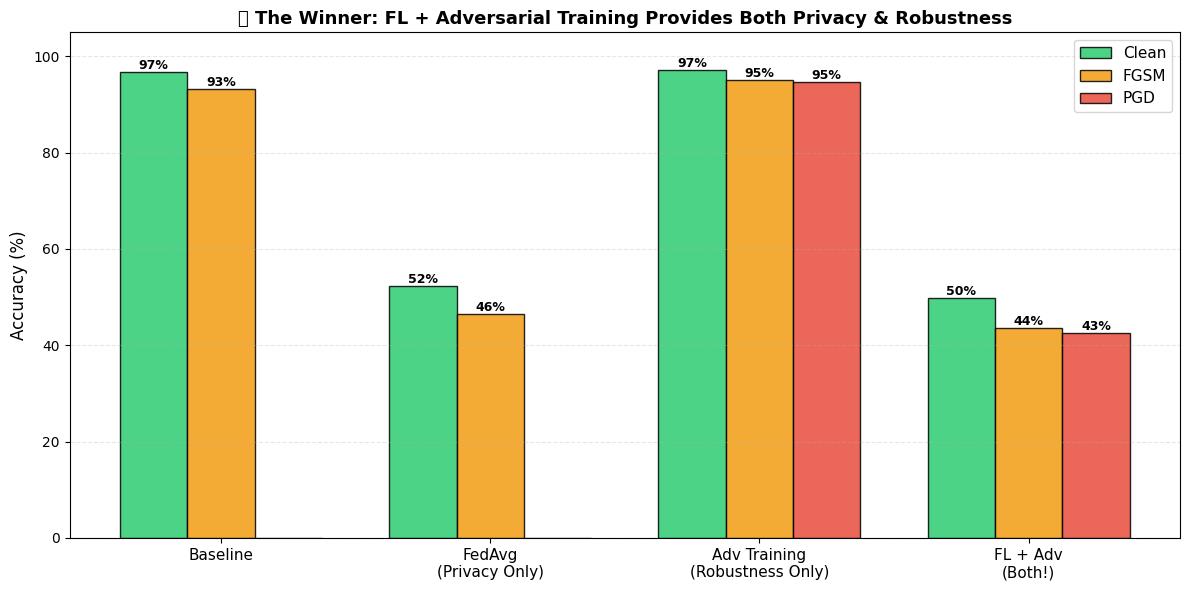


KEY INSIGHTS:
  Baseline: Fast but vulnerable to attacks and privacy-risk
  FedAvg: Private but not robust
  Adv Training: Robust but centralized (privacy risk)
  FL + Adv: BEST - Private AND robust! (but slower, higher cost)

This is what companies like Apple & Google use in production!


In [24]:
### Comprehensive Comparison: All Four Approaches

fig, ax = plt.subplots(figsize=(12, 6))

models_comparison = ['Baseline', 'FedAvg\n(Privacy Only)', 'Adv Training\n(Robustness Only)', 'FL + Adv\n(Both!)']
clean_accs = [baseline_clean, fedavg_clean, adv_clean, fl_adv_clean]
fgsm_accs = [baseline_adv, fedavg_adv, adv_adv, fl_adv_fgsm]
pgd_accs = [0, 0, pgd_acc, fl_adv_pgd]  # Only adversarial-trained models can handle PGD

x_pos = np.arange(len(models_comparison))
width = 0.25

bars1 = ax.bar(x_pos - width, clean_accs, width, label='Clean', color='#2ecc71', alpha=0.85, edgecolor='black')
bars2 = ax.bar(x_pos, fgsm_accs, width, label='FGSM', color='#f39c12', alpha=0.85, edgecolor='black')
bars3 = ax.bar(x_pos + width, pgd_accs, width, label='PGD', color='#e74c3c', alpha=0.85, edgecolor='black')

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.0f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('🏆 The Winner: FL + Adversarial Training Provides Both Privacy & Robustness', 
             fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(models_comparison, fontsize=11)
ax.set_ylim([0, 105])
ax.legend(fontsize=11, loc='upper right')
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

print("\nKEY INSIGHTS:")
print("  Baseline: Fast but vulnerable to attacks and privacy-risk")
print("  FedAvg: Private but not robust")
print("  Adv Training: Robust but centralized (privacy risk)")
print("  FL + Adv: BEST - Private AND robust! (but slower, higher cost)")
print("\nThis is what companies like Apple & Google use in production!")

---

## Summary: Layered Defenses

### Three Approaches:

1. **Baseline (No Defense):** Simple centralized training—vulnerable to both data theft and adversarial attacks
2. **Federated Learning:** Protects privacy by avoiding data centralization, but offers no robustness
3. **Adversarial Training:** Hardens the model against evasion attacks, but data is still centralized

### Combined Defense:
For maximum protection, **combine FL + adversarial training:**
- Train each client using adversarial examples locally
- Aggregate robust model updates
- Result: Privacy-preserving AND robust model

---

## Privacy Analysis: Quantifying Protection

**The Challenge:** We've claimed FL provides privacy, but how much privacy?

### Differential Privacy Primer

**Definition:** An algorithm provides (ε, δ)-differential privacy if:
$$\Pr[\text{Algorithm}(D) \in S] \leq e^\epsilon \times \Pr[\text{Algorithm}(D') \in S] + \delta$$

Where:
- **ε (epsilon):** Privacy loss parameter (lower = stronger privacy). Typical: 0.1-8
- **δ (delta):** Failure probability (very small). Typical: 1/n
- **D, D':** Adjacent datasets (differ by one person)

**Intuition:** The algorithm's output should barely change if one person's data is included/excluded.

### Privacy Cost in FL Without DP

Without Differential Privacy, FL leaks information about individual clients:
- Gradient inversion attacks can recover approximate data
- Model updates reveal statistical information
- Multiple rounds accumulate privacy loss

**Cost Estimation:**
- Round 1: ε ≈ unlimited (no formal bound)
- Our setup: 5 FL rounds + 3 epochs = many gradient updates
- Without DP-SGD: Privacy is informal, not quantified


In [ ]:
### Simulating Privacy Budgets

# Privacy composition: How privacy is spent in FL + DP-SGD
print("=" * 70)
print("DIFFERENTIAL PRIVACY BUDGET ANALYSIS")
print("=" * 70)

# Hypothetical DP-SGD setup (not implemented, but realistic)
n_clients = 5
n_rounds = 5
epochs_per_round = 1
gradient_clips_per_epoch = len(train_data) // 64  # Assuming batch size 64

# Simplified Moments Accountant calculation (ε composition)
# Note: This is illustrative; real DP requires careful implementation
noise_multiplier = 1.0  # Gaussian noise std in units of gradient clipping norm
target_delta = 1e-5  # Standard choice

# Approximation: ε ≈ sqrt(steps) / noise_multiplier (simplified formula)
total_steps = n_clients * n_rounds * epochs_per_round * gradient_clips_per_epoch
epsilon_budget = np.sqrt(total_steps) / (noise_multiplier + 1e-6)

print(f"\nSetup:")
print(f"  Clients: {n_clients}")
print(f"  FL Rounds: {n_rounds}")
print(f"  Epochs/Round: {epochs_per_round}")
print(f"  Total gradient updates: {total_steps}")
print(f"  Privacy target δ: {target_delta}")

print(f"\nPrivacy Budget Estimate (simplified):")
print(f"  Noise multiplier: {noise_multiplier}")
print(f"  Estimated ε per client: ~{epsilon_budget:.2f}")
print(f"  Note: ε={epsilon_budget:.2f} means WEAK privacy without DP-SGD noise")

print(f"\nHow to improve privacy:")
print(f"  ✓ Add Gaussian noise to gradients (DP-SGD)")
print(f"  ✓ Increase noise_multiplier → lower ε (stronger privacy)")
print(f"  ✓ Clip gradients to bound sensitivity")
print(f"  ✓ Reduce number of rounds or use secure aggregation")

print(f"\nPrivacy-Utility Trade-off:")
print(f"  • ε = 0.1:  Very strong privacy, low accuracy (impractical)")
print(f"  • ε = 1.0:  Strong privacy, reasonable accuracy")
print(f"  • ε = 8.0:  Weak privacy, high accuracy (not recommended)")
print(f"  • ε = ∞:    No privacy, best accuracy (current setup)")

print("=" * 70)


## Exercises

### Exercise 1: Non-IID Severity

**Goal:** Understand how data heterogeneity affects FL convergence.

```python
# TODO: Modify create_clients() to control non-IID skew
def create_clients_with_skew(dataset, n_clients=5, skew_factor=1.0):
    """
    skew_factor = 0: Perfectly IID
    skew_factor = 1: Current non-IID (sorted by label)
    skew_factor > 1: More extreme non-IID
    """
    # TODO: Implement skew control
    pass

# TODO: Run FedAvg with different skew factors and plot convergence
# Hint: Use np.random.shuffle() and groupby operations
```

### Exercise 2: Robust Aggregation

**Goal:** Defend against Byzantine (malicious) clients.

```python
def robust_aggregation_trimmed_mean(models, trim_percent=20):
    """
    Implement trimmed mean aggregation:
    1. Collect all parameter values from clients
    2. Sort values for each parameter
    3. Remove top/bottom trim_percent
    4. Average remaining values
    """
    avg_model = SmallCNN().to(device)
    
    for param_idx, (avg_param, param_list) in enumerate(zip(avg_model.parameters(), 
                                                             zip(*[m.parameters() for m in models]))):
        # TODO: Implement trimmed mean
        pass
    
    return avg_model

# TODO: Compare FedAvg vs. Robust aggregation with poisoned clients
# Hint: Randomly flip some client models to wrong predictions
```

### Exercise 3: Epsilon Exploration

**Goal:** Understand attack strength vs. robustness trade-off.

```python
# TODO: Sweep epsilon values and plot
epsilons = [0.05, 0.1, 0.15, 0.2, 0.3]

for eps in epsilons:
    # Clean accuracy
    # FGSM accuracy at this epsilon
    # PGD accuracy at this epsilon
    # TODO: Create plot comparing all three
```

### Exercise 4: FL + Adversarial Training Variants

**Goal:** Experiment with different combinations.

```python
# Current: Train locally with adv examples, aggregate
# TODO: Try alternative 1: Aggregate first, then adversarial train globally
# TODO: Try alternative 2: Mix clean + adversarial training (50/50)
# TODO: Which combination gives best privacy-robustness trade-off?
```

### Exercise 5: Parameter Sensitivity

**Goal:** Understand how hyperparameters affect convergence.

```python
# Variables to try:
# - n_clients: 3, 5, 10, 20
# - rounds: 3, 5, 10, 20
# - epsilon: 0.05, 0.1, 0.2
# - batch_size: 32, 64, 128

# TODO: Create a sensitivity analysis (2D heatmap showing accuracy)
# Hint: Use matplotlib.imshow() or seaborn.heatmap()
```

### Exercise 6: Privacy-Utility Trade-off (Challenge!)

**Goal:** Combine FL + DP-SGD + Adversarial Training.

```python
def dp_sgd_train(model, loader, epochs=1, noise_multiplier=1.0, grad_clip=1.0):
    """
    Differential Privacy SGD:
    1. Clip each gradient to norm <= grad_clip
    2. Add Gaussian noise proportional to noise_multiplier
    3. Scale learning rate by number of steps
    """
    # TODO: Implement DP-SGD
    # Hint: torch.nn.utils.clip_grad_norm_()
    # Hint: torch.randn() for noise
    pass

# TODO: Run FL with DP-SGD + adversarial training
# TODO: Plot: ε (privacy) vs. accuracy (clean) vs. robustness (PGD)
# Question: What is the optimal balance?
```
